# Dataset Check

In [1]:
import sys
import os

os.chdir("..")
from dataset import LabeledDetectionDataset, UnlabeledDetectionDataset

Paths to data:

In [2]:
from pathlib import Path
import pandas as pd
from training import explore_dataset

df = explore_dataset(Path("../data_det_public/data_det_public"))

C:\workspace\git\single-class-detection\src\DET_524839\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import numpy as np

MEAN = [81.7474, 59.7219, 70.0178]
STD = [47.6729, 41.8091, 46.3294]

def denormalize(image: torch.Tensor):
    image = image.cpu().numpy()
    image = image.copy()
    for i in range(3):
        image[:, :, i] = image[:, :, i] * STD[i] + MEAN[i]
    return image
    
def show_sample(sample: tuple[torch.Tensor, dict, torch.Tensor]) -> None:
    img, metadata, bboxes = sample
    img = img.permute(1, 2, 0)
    img = denormalize(img)
    img = img.astype(np.uint8)

    fig, ax = plt.subplots(1)
    ax.imshow(img)

    for box in bboxes:
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min), width, height, linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
    
    plt.axis('off')
    plt.show()

Observe produced samples by the datasets:

## Unlabeled

In [4]:
from training import TRAIN_TRANSFORMS

unlabeled_df = UnlabeledDetectionDataset(df, TRAIN_TRANSFORMS)

In [ ]:
SAMPLE_IDX = 92

im, meta = unlabeled_df[SAMPLE_IDX]
print(im.shape)
print(im.mean(dim=[1, 2]))
print(im.std(dim=[1, 2]))
print(meta)

## Labeled

In [6]:
labeled_df = LabeledDetectionDataset(df, TRAIN_TRANSFORMS)

In [9]:
SAMPLE_IDX = 73

im, meta, label = labeled_df[SAMPLE_IDX]
print(im.shape)
print(label)
print(meta)

torch.Size([3, 512, 1024])
tensor([[ 789.4393,   90.7274,  994.2532,  218.4550],
        [ 839.2558,   92.2644,  992.4933,  206.5980],
        [ 929.5243,   77.2559, 1024.0000,  212.5652],
        [ 988.6163,  121.7734, 1024.0000,  227.5393],
        [ 299.5879,  214.4038,  458.1693,  309.3675],
        [ 237.1500,  238.7895,  373.4185,  345.8857],
        [ 612.9078,  138.2330,  795.0420,  291.2073],
        [ 113.2061,  236.1331,  359.7460,  375.6402],
        [ 119.0905,  255.0337,  325.7984,  419.1073],
        [   0.0000,  277.0342,  202.2118,  480.4503]])
{'filename': 'aachen_000084_000019_leftImg8bit.png', 'n_labeled_cars': np.int64(10), 'city': 'aachen'}


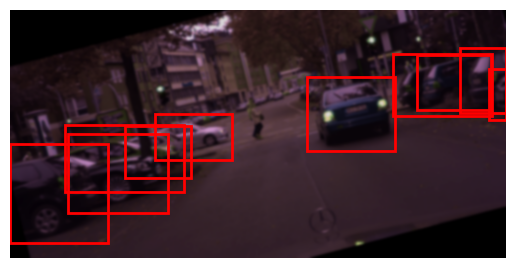

In [10]:
show_sample( (im, meta, label) )